# Import Libraries and read file

In [2]:
import pandas as pd
import os

low_x0, low_y0, low_w, low_h, bottom_z, top_z = 0, 0, 256, 256, 0, 256 # -500, -500, 1000, 1000, -500, 500

def get_velz_dens(x_range, y_range, z_range):
    # read a 3D grid of velz and density array
    velz = obj["flash", "velz"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value        
    dens = obj["flash", "dens"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('g/cm**3').value        
    temp = obj["flash", "temp"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('K').value 

    print(f"obj.shape: {obj['flash', 'velz'].shape}")
    print("x, y, z ranges: ", x_range, y_range, z_range)
    print(f"velz.shape: {velz.shape}\tdens.shape: {dens.shape}\n\n")      
     

    dz = obj['flash', 'dz'][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('cm').value
    mp = yt.physical_constants.mp.value # proton mass

    # calculate the density as column density
    coldens = dens * dz / (1.4 * mp)

    return velz, coldens, temp

def get_velx_vely(x_range, y_range, z_range):
    # read a 3D grid of vely and density array
    vely = obj["flash", "vely"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    velx = obj["flash", "velx"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    
    print(f"velx.shape: {velx.shape}\tvely.shape: {vely.shape}\n\n")      
    
    return velx, vely

# convert seconds to Megayears
def seconds_to_megayears(seconds):
    return seconds / (1e6 * 365 * 24 * 3600)

def pc2pixel(coord, x_y_z):
    if x_y_z == "x":
        return coord + top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord + top_z
    return coord

def pixel2pc(coord, x_y_z):
    if x_y_z == "x":
        return coord - top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord - top_z
    return coord

def cm2pc(cm):
    return cm * 3.24077929e-19

# filter the DataFrame
# def filter_data(df, range_coord):
#     return df[(df['posx_pc'] > range_coord[0]) & (df['posx_pc'] < range_coord[0] + range_coord[2]) & (df['posy_pc'] > range_coord[1]) & (df['posy_pc'] < range_coord[1] + range_coord[3]) & (df['posz_pc'] > range_coord[4] & (df['posz_pc'] < range_coord[5]))]

def timestamp2Myr(timestamp):
    return (timestamp - 200) * 0.1 + 191

def time_Myr2timestamp(time_Myr):
    return round(10 * (time_Myr - 191) + 200)

In [3]:
import matplotlib.pyplot as plt
import yt
import numpy as np
import os 
import matplotlib.colors as colors

# elephant
hdf5_root = "/srv/data/stratbox_simulations/stratbox_particle_runs/bx5/smd132/sn34/pe300/4pc_resume/4pc"

# mac
# hdf5_root = "~/Desktop/UBC/Research/Program/Dataset/raw_hdf5"

time_Myr = 228

ds = yt.load(os.path.join(hdf5_root, 'sn34_smd132_bx5_pe300_hdf5_plt_cnt_0{}'.format(time_Myr2timestamp(time_Myr))))

center = [0, 0, 0] * yt.units.pc
arb_center = ds.arr(center, 'code_length')
xlim = 256
ylim = 256
zlim= 256
left_edge = arb_center + ds.quan(-500, 'pc')
right_edge = arb_center + ds.quan(500, 'pc')
obj = ds.arbitrary_grid(left_edge, right_edge, dims=(256,256,256))

yt : [INFO     ] 2024-08-20 19:15:04,739 Particle file found: sn34_smd132_bx5_pe300_hdf5_part_0570
yt : [INFO     ] 2024-08-20 19:15:04,838 Parameters: current_time              = 7195152504692308.0
yt : [INFO     ] 2024-08-20 19:15:04,839 Parameters: domain_dimensions         = [  32   32 1280]
yt : [INFO     ] 2024-08-20 19:15:04,840 Parameters: domain_left_edge          = [-1.54283879e+21 -1.54283879e+21 -6.17135516e+22]
yt : [INFO     ] 2024-08-20 19:15:04,841 Parameters: domain_right_edge         = [1.54283879e+21 1.54283879e+21 6.17135516e+22]
yt : [INFO     ] 2024-08-20 19:15:04,841 Parameters: cosmological_simulation   = 0


In [4]:
# retrieve the center (100, 100, 100) grid, zoom in the explosion


# Multiply each element within the tuples by the multiplier
x_range_scaled = (0, 255) 
y_range_scaled = (0, 255)  
z_range_scaled = (0, 255)
# # z_range_scaled = (65, 217) #tuple(int(z * multiplier) for z in z_range)

# center_x, center_y, center_z = int(pc2pixel(85, x_y_z="x") * 256/1000), int(pc2pixel(196, x_y_z="x") * 256/1000), int(pc2pixel(53, x_y_z="z") * 256/1000)
# print(center_x, center_y, center_z, time_Myr)

# center_x = center_x - x_range_scaled[0]
# center_y = center_y - y_range_scaled[0]
# center_z = center_z - z_range_scaled[0]

center_x, center_y, center_z = 128, 128, 128

new_velz, new_dens, new_temp = get_velz_dens(x_range_scaled, y_range_scaled, z_range_scaled)
new_velx, new_vely = get_velx_vely(x_range_scaled, y_range_scaled, z_range_scaled)


obj.shape: (256, 256, 256)
x, y, z ranges:  (0, 255) (0, 255) (0, 255)
velz.shape: (255, 255, 255)	dens.shape: (255, 255, 255)


velx.shape: (255, 255, 255)	vely.shape: (255, 255, 255)




# point out all the SN explosions

In [5]:
import pandas as pd
from glob import glob
import os

filename = "SNfeedback.dat"
dat_files = glob(os.path.join(hdf5_root, filename))

all_data = pd.DataFrame()

# Read and concatenate data from all .dat files
for dat_file in dat_files:
    # Assuming space-separated values in the .dat files
    df = pd.read_csv(dat_file, delim_whitespace=True, header=None,
                     names=['n_SN', 'type', 'n_timestep', 'n_tracer', 'time',
                            'posx', 'posy', 'posz', 'radius', 'mass'])
    
    # Convert the columns to numerical
    df = df.iloc[1:]
    df['n_SN'] = df['n_SN'].map(int)
    df['type'] = df['type'].map(int)
    df['n_timestep'] = df['n_timestep'].map(int)
    df['n_tracer'] = df['n_tracer'].map(int)
    df['time'] = pd.to_numeric(df['time'],errors='coerce')
    df['posx'] = pd.to_numeric(df['posx'],errors='coerce')
    df['posy'] = pd.to_numeric(df['posy'],errors='coerce')
    df['posz'] = pd.to_numeric(df['posz'],errors='coerce')
    df['radius'] = pd.to_numeric(df['radius'],errors='coerce')
    df['mass'] = pd.to_numeric(df['mass'],errors='coerce')
    all_data = pd.concat([all_data, df], ignore_index=True)
    all_data = all_data.drop(df[df['n_tracer'] != 0].index)


# Convert time to Megayears
all_data['time_Myr'] = seconds_to_megayears(all_data['time'])

# Convert 'pos' from centimeters to parsecs
all_data['posx_pc'] = cm2pc(all_data['posx'])
all_data['posy_pc'] = cm2pc(all_data['posy'])
all_data['posz_pc'] = cm2pc(all_data['posz'])

# Sort the DataFrame by time in ascending order
all_data.sort_values(by='time_Myr', inplace=True)

def pix_256_2pc(pix_256):
    return pix_256 * (1000 / 256)

def pc2pix_256(pc):
    return pc * (256 / 1000)

# # convert the cube range to pc
# low_x0, low_y0, low_w, low_h, bottom_z, top_z = 0, 0, 256, 256, 0, 256      # pixel
# low_x0, low_y0, low_w, low_h, bottom_z, top_z = pix_256_2pc(low_x0), pix_256_2pc(low_y0), pix_256_2pc(low_w), pix_256_2pc(low_h), pix_256_2pc(bottom_z), pix_256_2pc(top_z)

low_x0, low_y0, low_w, low_h, bottom_z, top_z = 0, 0, 1000, 1000, 0, 1000
range_coord = [low_x0, low_y0, low_w, low_h, bottom_z, top_z]

start_Myr = 209
end_yr = start_Myr + 1

def filter_data(df, range_coord):
    return df[(df['posx_pc'] > range_coord[0]) & (df['posx_pc'] < range_coord[0] + range_coord[2]) & 
              (df['posy_pc'] > range_coord[1]) & (df['posy_pc'] < range_coord[1] + range_coord[3]) & 
              (df['posz_pc'] > range_coord[4]) & (df['posz_pc'] < range_coord[5])]


# Filter data based on specified conditions
filtered_data = all_data[(all_data['time_Myr'] >= start_Myr) & (all_data['time_Myr'] <= end_yr)]
# filtered_data = filter_data(all_data[(all_data['time_Myr'] >= start_Myr) & (all_data['time_Myr'] <= end_yr)],
                            # (low_x0, low_y0, low_w, low_h, bottom_z, top_z))

filtered_data

converted_points = list(zip(
    pc2pix_256(filtered_data['posx_pc']) + 128,
    pc2pix_256(filtered_data['posy_pc']) + 128,
    pc2pix_256(filtered_data['posz_pc']) + 128
))

converted_points

[(149.49999974375484, 178.50000028564313, 141.50000010921707),
 (213.500000138615, 19.500003608417245, 82.49999969335286),
 (27.50000158367604, 66.50000042427729, 173.50000030664714),
 (23.500002596046627, 239.49999770640352, 161.500000025201),
 (162.50000018692808, 111.50000023524115, 145.49999992648594),
 (1.500004015887498, 106.50000025624517, 127.5000000021004),
 (15.499996324392882, 234.50000104596555, 137.50000029194817),
 (128.4999999978996, 212.5000024658064, 139.49999978576287),
 (96.50000029825321, 95.5000001365261, 138.49999962403578),
 (41.50000218857639, 73.49999989708797, 132.49999998109638),
 (228.49999841632396, 252.5000006384953, 115.50000005251005),
 (114.49999989078295, 73.49999989708797, 134.49999997269478),
 (106.50000025624517, 67.4999997563649, 176.49999996218895),
 (199.50000036335416, 77.49999971435687, 109.49999991178696),
 (140.49999994748995, 46.499999678653865, 127.5000000021004),
 (241.50000134841574, 145.49999992648594, 88.49999983407594),
 (139.499999785

## Edge Mask generation
- Density slice
    - threholding, then connected component
    - keep only the center mask, or SB230 that we wanted
- Ring Mask
    - dilate then subtract the original mask
    - retrieve the ring mask for each slice (repeat for all slices the blob span)  

In [6]:
import cv2
def apply_otsus_thresholding(image):
    # _, threshold = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # return threshold
    _, binary_image = cv2.threshold(image.astype("uint8"), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return cv2.bitwise_not(binary_image)

def within_range(min, max, target):
    if min < target and max > target:
        return True
    return False

def SN_center_in_bubble(posx_px, posy_px, x1, y1, w, h):
    if within_range(x1, x1 + w, posx_px) and within_range(y1, y1 + h, posy_px):
        return True
    return False

def normalize4thresholding(arr):
    slice = np.log10(arr)
    return ((slice - np.min(slice)) / (np.max(slice) - np.min(slice))) * 255 

def plot_dens_z(dens, center_z):
    fig, ax = plt.subplots()
    im = ax.imshow(np.log10(dens[:, :, center_z].T[::]), cmap='viridis', aspect='auto')
    fig.colorbar(im, label='density ($g*cm^{-2}$)')
    plt.title('Density ($g*cm^{-2}$)')
    plt.xlabel('X')
    plt.ylabel('Y')
    # fig.savefig(f'../expanding_velocity/{time_Myr}/dzoom_{center_z}.png')
    plt.show()

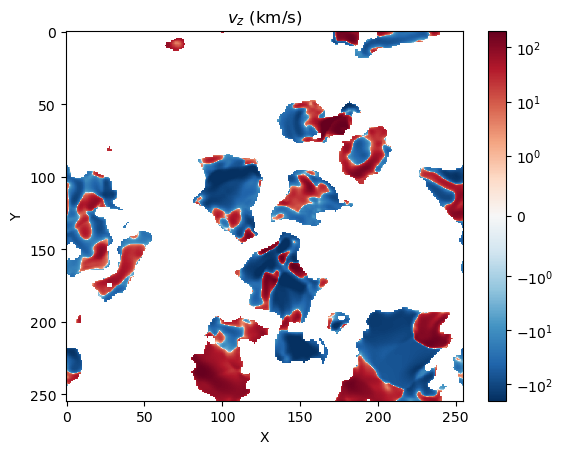

In [7]:
# read density slice
lower_b = 0
upper_b = 255
cube_size = 255
# input_point = (center_x, center_y)
mask = np.zeros((cube_size, cube_size, upper_b - lower_b))
dilated_stack = np.zeros((cube_size, cube_size, upper_b - lower_b))

for current_z in range(upper_b - lower_b):
    dens_slice = normalize4thresholding(new_dens[:, :, current_z + lower_b]) 

    # cv2.imwrite(f"tmp/dens_{current_z}.png", dens_slice)
    # dens_img = cv2.imread(f"tmp/dens_{current_z}.png")
    
    # threshold + connected component
    binary_mask = apply_otsus_thresholding(dens_slice)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    # retrieve all mask only
    i = 0
    x, y, w, h, area = stats[i]
    binary_mask = labels == i
    binary_mask = ~binary_mask
    mask[:, :, current_z] = binary_mask
    # binary_mask = binary_mask * 255



# cast the ring of mask over velz and dens array, plot out the velocity profile, with integrated density as a function of velz  
velz_roi = np.where(mask, new_velz[:, :, lower_b:upper_b], np.nan)
dens_roi = np.where(mask, new_dens[:, :, lower_b:upper_b], np.nan)

# plt.plot(velz_roi[:, center_y, 25].T)
plt.imshow(velz_roi[:, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
plt.colorbar()

plt.title('$v_z$ (km/s)')
plt.xlabel('X')
plt.ylabel('Y')
# plt.savefig(f'graphs/{time_Myr}/ringed_velz_{center_z}.png')
plt.show()



In [73]:
# saving the interesting region into a seperate file    
np.savez("./visualization/dens_velz_roi.npz", dens_roi, velz_roi)
# data = np.load('./visualization/dens_velz_roi.npz')

# Plotting the 3D structure in K3D

In [7]:
import k3d
import numpy as np
from k3d import matplotlib_color_maps

coords = np.argwhere(~np.isnan(velz_roi))

values = velz_roi[coords[:, 0], coords[:, 1], coords[:, 2]]

plt_points = k3d.points(positions=coords,
                        point_size=0.5,
                        shader='3d',
                        opacity=0.85,
                        color_map=matplotlib_color_maps.Coolwarm,
                        attribute=values,
                        color_range=[-2, 2]
                        ) # shader='3d', color=0x3f6bc5

plot = k3d.plot(grid=(0, 0, 0, 10, 10, 10),
                axes=['X', 'Y', 'Z'])


plot += plt_points
plot.display()

/UBC-O/ashill01/anaconda3/envs/joy_env/lib/python3.10/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

In [8]:
import k3d
import numpy as np
from k3d import matplotlib_color_maps


coords = np.argwhere(~np.isnan(dens_roi))

values = np.log10(dens_roi[coords[:, 0], coords[:, 1], coords[:, 2]])

plt_points = k3d.points(positions=coords,
                        point_size=0.7,
                        shader='3d',
                        opacity=0.85,
                        color_map=matplotlib_color_maps.Viridis,
                        attribute=values,
                        ) # shader='3d', color=0x3f6bc5
SB_center = k3d.points(positions = [149, 178, 141], #converted_points, 
                        point_size=9.0,
                        shader='3d',
                        opacity=1,
                        color=0xc30010)     # original point: [149, 178, 141]

plot = k3d.plot(grid=(0, 0, 0, 10, 10, 10),
                axes=['X', 'Y', 'Z'])


plot += plt_points
plot += SB_center
plot.display()

# with open('./tmp/whole_cube_dens.html','w') as fp:
#     fp.write(plot.get_snapshot())

/UBC-O/ashill01/anaconda3/envs/joy_env/lib/python3.10/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

# Extracting the ring masks

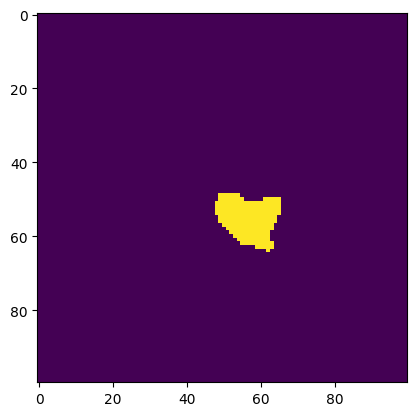

In [ ]:
# read density slice
lower_b = 0
upper_b = 100
input_point = (center_x, center_y)
mask = np.zeros((100, 100, upper_b - lower_b))
dilated_stack = np.zeros((100, 100, upper_b - lower_b))
target_mask = np.zeros((100, 100))


for current_z in range(upper_b - lower_b):
    dens_slice = normalize4thresholding(new_dens[:, :, current_z + lower_b]) 

    # visualize the dens slice to see the bubble
    # plot_dens_z(dens = new_dens, center_z = current_z)
    
    # threshold + connected component
    binary_mask = apply_otsus_thresholding(dens_slice)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    # Check each component's bounding box to find the target mask
    for i in range(3, num_labels):  # Starting from 1 to ignore the background
        x, y, w, h, area = stats[i]
        
        # Check if the center point is within the bounding box
        if SN_center_in_bubble(input_point[0], input_point[1], x, y, w, h):     # and area < 10 * 427
            # If yes, fill the target_mask with this component
            binary_mask = labels == i
            
            # Save the target mask
            mask[:, :, current_z] = binary_mask
            target_mask = np.where(labels == i, 255, 0).astype('uint8')

            break 


    # dilate the binary mask for 3 pixels
    kernel = np.ones((5, 5), np.uint8)
    
    # outside mask
    dilated_mask = cv2.dilate(target_mask, kernel, iterations=1)
    dilated_stack[:, :, current_z] = dilated_mask

    # subtract the dilated mask with the original binary mask to retrieve the boundary edge for the sphere
boundary_edge = np.logical_xor(mask, dilated_stack).astype(float)

# cast the ring of mask over velz and dens array, plot out the velocity profile, with integrated density as a function of velz  
velz_ring_roi = np.where(boundary_edge, new_velz[:, :, lower_b:upper_b], np.nan)
dens_ring_roi = np.where(boundary_edge, new_dens[:, :, lower_b:upper_b], np.nan)

# plt.imshow(velz_ring_roi[:, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
#                 norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
# plt.colorbar()

# plt.title('$v_z$ (km/s)')
# plt.xlabel('X')
# plt.ylabel('Y')
# # plt.savefig(f'graphs/{time_Myr}/ringed_velz_{center_z}.png')
# plt.show()



In [17]:
coords = np.argwhere(~np.isnan(dens_ring_roi))

values = np.log10(dens_ring_roi[coords[:, 0], coords[:, 1], coords[:, 2]])

plt_points = k3d.points(positions=coords,
                        point_size=0.7,
                        shader='flat',
                        opacity=0.5,
                        color_map=matplotlib_color_maps.Viridis,
                        attribute=values,
                        ) # shader='3d', color=0x3f6bc5

plot = k3d.plot(grid=(0, 0, 0, 10, 10, 10),
                axes=['X', 'Y', 'Z'])


plot += plt_points
plot.display()

Output()

In [20]:
coords = np.argwhere(~np.isnan(velz_ring_roi))

values = velz_ring_roi[coords[:, 0], coords[:, 1], coords[:, 2]]

plt_points = k3d.points(positions=coords,
                        point_size=0.7,
                        shader='flat',
                        opacity=0.5,
                        color_map=matplotlib_color_maps.Coolwarm,
                        attribute=values,
                        color_range=[-2, 2]
                        ) # shader='3d', color=0x3f6bc5

plot = k3d.plot(grid=(0, 0, 0, 10, 10, 10),
                axes=['X', 'Y', 'Z'])


plot += plt_points
plot.display()

/UBC-O/joy0921/Desktop/Program/AstroSegTrack/.venv/lib/python3.10/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

In [ ]:
# organized the ring mask coordinates into dictionary, one slice per record

ringed_stack = {}

for z in range(upper_b - lower_b):
    ringed_mask = {'coord_x': [], 'coord_y': [],'velz': [], 'dens': []}
    binary_mask = boundary_edge[:, :, z]
    coords = np.where(binary_mask == 1)

 
    # coords = np.column_stack(np.where(binary_mask == 1))

    velz_values = velz_roi[coords[0], coords[1], z + lower_b]
    dens_values = dens_roi[coords[0], coords[1], z + lower_b]

    # print(coords[0].size)


    ringed_mask['coord_x'].extend(coords[0].tolist())
    ringed_mask['coord_y'].extend(coords[1].tolist())
    
    ringed_mask['velz'].extend(velz_values.tolist())
    ringed_mask['dens'].extend(dens_values.tolist())

    ringed_stack[z] = ringed_mask

# Figuring out the ringed artifact

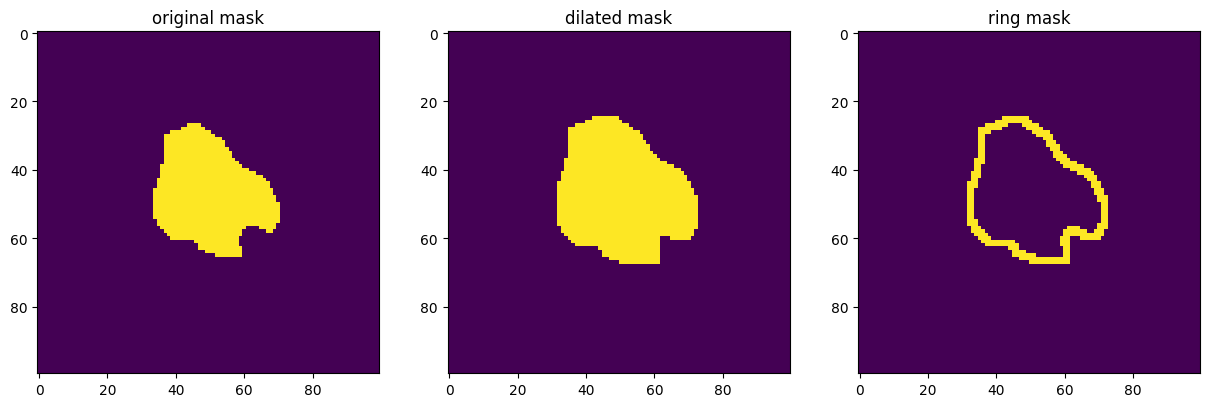

In [25]:
for mask_z in range(lower_b, upper_b):
    f = plt.figure(figsize=(15, 5))
    ax = f.add_subplot(131)
    ax2 = f.add_subplot(132)
    ax3 = f.add_subplot(133)

    ax.imshow(mask[:, :, mask_z])
    ax.set_title("original mask")
    ax2.imshow(dilated_stack[:, :, mask_z])
    ax2.set_title("dilated mask")
    ax3.imshow(boundary_edge[:, :, mask_z])
    ax3.set_title("ring mask")
    
    plt.savefig(f"./tmp/{mask_z}.png")